In [26]:
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

## Load Dataset

In [27]:
df = pd.read_csv("./data/ann_dataset.csv")


In [28]:
df = df.drop(["date"],axis=1)
df.head()

,Name,close_t-1,close_t-2,close_t-3,close_t-4,close_t-5,target
0,A,28.563612,28.672525,28.589230,28.576422,28.883968,27.070713
1,A,27.070713,28.563612,28.672525,28.589230,28.576422,27.557655
2,A,27.557655,27.070713,28.563612,28.672525,28.589230,27.064302
3,A,27.064302,27.557655,27.070713,28.563612,28.672525,26.673462
4,A,26.673462,27.064302,27.557655,27.070713,28.563612,26.782379


In [29]:
df.shape

(434977, 7)

## Tuning parameters of the baseline model

As we're using the adjusted prices and we already cleaned the data, We could use any stock

In [30]:
stocks_in_data = df["Name"].unique()
print(len(stocks_in_data))

442


In [44]:

stocks_seleccionados = stocks_in_data[:6]

diccionario_stocks = {}

for stock in stocks_seleccionados:
    data_to_train = df[df["Name"] == stock]
    diccionario_stocks[stock] = data_to_train

data_to_train = df[df["Name"] == stocks_in_data[0]]
data_to_train.head()

,Name,close_t-1,close_t-2,close_t-3,close_t-4,close_t-5,target
0,A,28.563612,28.672525,28.589230,28.576422,28.883968,27.070713
1,A,27.070713,28.563612,28.672525,28.589230,28.576422,27.557655
2,A,27.557655,27.070713,28.563612,28.672525,28.589230,27.064302
3,A,27.064302,27.557655,27.070713,28.563612,28.672525,26.673462
4,A,26.673462,27.064302,27.557655,27.070713,28.563612,26.782379


In [45]:
data_to_train.shape

(1000, 7)

## Obtain train and test splits

In [33]:
train_percentage = 0.7

rows = data_to_train.shape[0]

train_size = int(rows * train_percentage)

train_df = data_to_train.iloc[:train_size]
test_df = data_to_train.iloc[train_size:]



## Normalize data

In [37]:
scaler = MinMaxScaler()

cols = ["close_t-1","close_t-2","close_t-3","close_t-4","close_t-5","target"]
train_df[cols] = scaler.fit_transform(train_df[cols])
test_df[cols] = scaler.transform(test_df[cols])

**Get train and test data**

In [38]:
X_train = train_df[["close_t-1","close_t-2","close_t-3","close_t-4","close_t-5"]]
y_train = train_df["target"]

X_test = test_df[["close_t-1","close_t-2","close_t-3","close_t-4","close_t-5"]]
y_test = test_df["target"]

In [39]:
X_train.head()

,close_t-1,close_t-2,close_t-3,close_t-4,close_t-5
0,0.182493,0.190358,0.184343,0.183418,0.205627
1,0.074686,0.182493,0.190358,0.184343,0.183418
2,0.109849,0.074686,0.182493,0.190358,0.184343
3,0.074223,0.109849,0.074686,0.182493,0.190358
4,0.045999,0.074223,0.109849,0.074686,0.182493


In [40]:
y_train.head()

0    0.074686
1    0.109849
2    0.074223
3    0.045999
4    0.053864
Name: target, dtype: float64

**To do the tuning of hyperparameters, we will set the humber of hidden layers fixed at two and the progressevly adjusting the number of neuron per hidden layer, from 1 neuron per layer to 25 neurons per layers**

In [41]:
resultados = []

for n in range(1, 26):  # de 1 a 25 neuronas
    
    model = keras.Sequential([
        layers.Dense(n, activation='sigmoid', input_shape=(5,)),
        layers.Dense(n, activation='sigmoid'),
        layers.Dense(1, activation='linear')
    ])
    
    model.compile(
        optimizer='adam',
        loss='mse'
    )
    
    # Entrenar
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    
    # Predecir
    y_pred = model.predict(X_test)
    
    # Calcular MAPE
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    resultados.append((n, mape))
    
    print(f"Neuronas: {n}, MAPE: {mape}")

/Users/sergio/Documents/NeuralNetworks/NeuralNetworks-Group1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Neuronas: 1, MAPE: 0.5333942796978244


/Users/sergio/Documents/NeuralNetworks/NeuralNetworks-Group1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Neuronas: 2, MAPE: 0.36386924200939424


/Users/sergio/Documents/NeuralNetworks/NeuralNetworks-Group1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neuronas: 23, MAPE: 0.09658500625416214


/Users/sergio/Documents/NeuralNetworks/NeuralNetworks-Group1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neuronas: 24, MAPE: 0.12758978914599775


/Users/sergio/Documents/NeuralNetworks/NeuralNetworks-Group1/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neuronas: 25, MAPE: 0.09179819536075011


In [42]:
for r in resultados:
    print(f"{r[0]} neuronas → MAPE: {r[1]}")

1 neuronas → MAPE: 0.5333942796978244
2 neuronas → MAPE: 0.36386924200939424
3 neuronas → MAPE: 0.3192095173833093
4 neuronas → MAPE: 0.34537089544613925
5 neuronas → MAPE: 0.1765534822459464
6 neuronas → MAPE: 0.2639026772050345
7 neuronas → MAPE: 0.1418813679217853
8 neuronas → MAPE: 0.18967818948094983
9 neuronas → MAPE: 0.21914124621670236
10 neuronas → MAPE: 0.19416435587680475
11 neuronas → MAPE: 0.1191000129889873
12 neuronas → MAPE: 0.13790200964823654
13 neuronas → MAPE: 0.1587505545485227
14 neuronas → MAPE: 0.16749645694014986
15 neuronas → MAPE: 0.16902123883046638
16 neuronas → MAPE: 0.13392974576221287
17 neuronas → MAPE: 0.20530914026598387
18 neuronas → MAPE: 0.12612525863079863
19 neuronas → MAPE: 0.11549866736482012
20 neuronas → MAPE: 0.12068614861507813
21 neuronas → MAPE: 0.12316573903451107
22 neuronas → MAPE: 0.10151947750500587
23 neuronas → MAPE: 0.09658500625416214
24 neuronas → MAPE: 0.12758978914599775
25 neuronas → MAPE: 0.09179819536075011


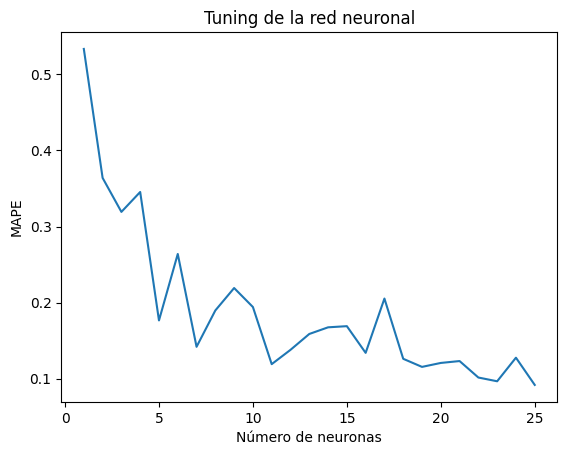

In [43]:


neuronas = [r[0] for r in resultados]
errores = [r[1] for r in resultados]

plt.plot(neuronas, errores)
plt.xlabel("Número de neuronas")
plt.ylabel("MAPE")
plt.title("Tuning de la red neuronal")
plt.show()